<a href="https://colab.research.google.com/github/abyansyah052/NLP-1/blob/main/PBACA_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## TUGAS 1A Scrapping Google Apps Review - BANK JAGO
Week 2 NLP Pipeline PBA/ Genap 2026/ Muhammad Abyansyah Putra Dewanto (5026231052)


In [1]:
!pip install google-play-scraper
!pip install textblob
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.6 MB/s eta 0:00:00


In [4]:
!pip install google-play-scraper textblob PySastrawi seaborn -q

from google_play_scraper import reviews_all, Sort
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re #   import regular expression
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
from collections import Counter
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (15, 10)
%matplotlib inline
%config InlineBackend.figure_format='retina'


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 4.7 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [6]:
APP_ID = "com.jago.digitalBanking"

jago_reviews = reviews_all(
    APP_ID,
    sleep_milliseconds=50,
    lang="id",
    country="id",
    sort=Sort.NEWEST
)

In [7]:
df_jagorev = pd.DataFrame(jago_reviews)
df_jagorev = df_jagorev[["userName", "score", "at", "content"]]

# Simpan raw data
df_jagorev.to_csv('df_jagorev.csv', index=False)
print(f"Scraped: {df_jagorev.shape}")
df_jagorev.head()

Scraped: (68189, 4)


,userName,score,at,content
0,Pengguna Google,3,2026-03-24 16:31:45,kata ny bisa meminjam kan uang .. ! sekali di ...
1,Pengguna Google,5,2026-03-24 15:34:32,ok amann
2,Pengguna Google,3,2026-03-24 14:40:16,mengapa aplikasi bank jago menu saya tidak ada...
3,Pengguna Google,5,2026-03-24 12:36:50,the best
4,Pengguna Google,5,2026-03-24 12:04:05,"kerenn, makasii bonusnya minn"


In [8]:
df_jagorev = pd.read_csv('df_jagorev.csv')
print(f"Loaded: {df_jagorev.shape}")
df_jagorev.head()

Loaded: (68189, 4)


,userName,score,at,content
0,Pengguna Google,3,2026-03-24 16:31:45,kata ny bisa meminjam kan uang .. ! sekali di ...
1,Pengguna Google,5,2026-03-24 15:34:32,ok amann
2,Pengguna Google,3,2026-03-24 14:40:16,mengapa aplikasi bank jago menu saya tidak ada...
3,Pengguna Google,5,2026-03-24 12:36:50,the best
4,Pengguna Google,5,2026-03-24 12:04:05,"kerenn, makasii bonusnya minn"


score
5    42287
1    16561
4     3687
3     3083
2     2571
Name: count, dtype: int64


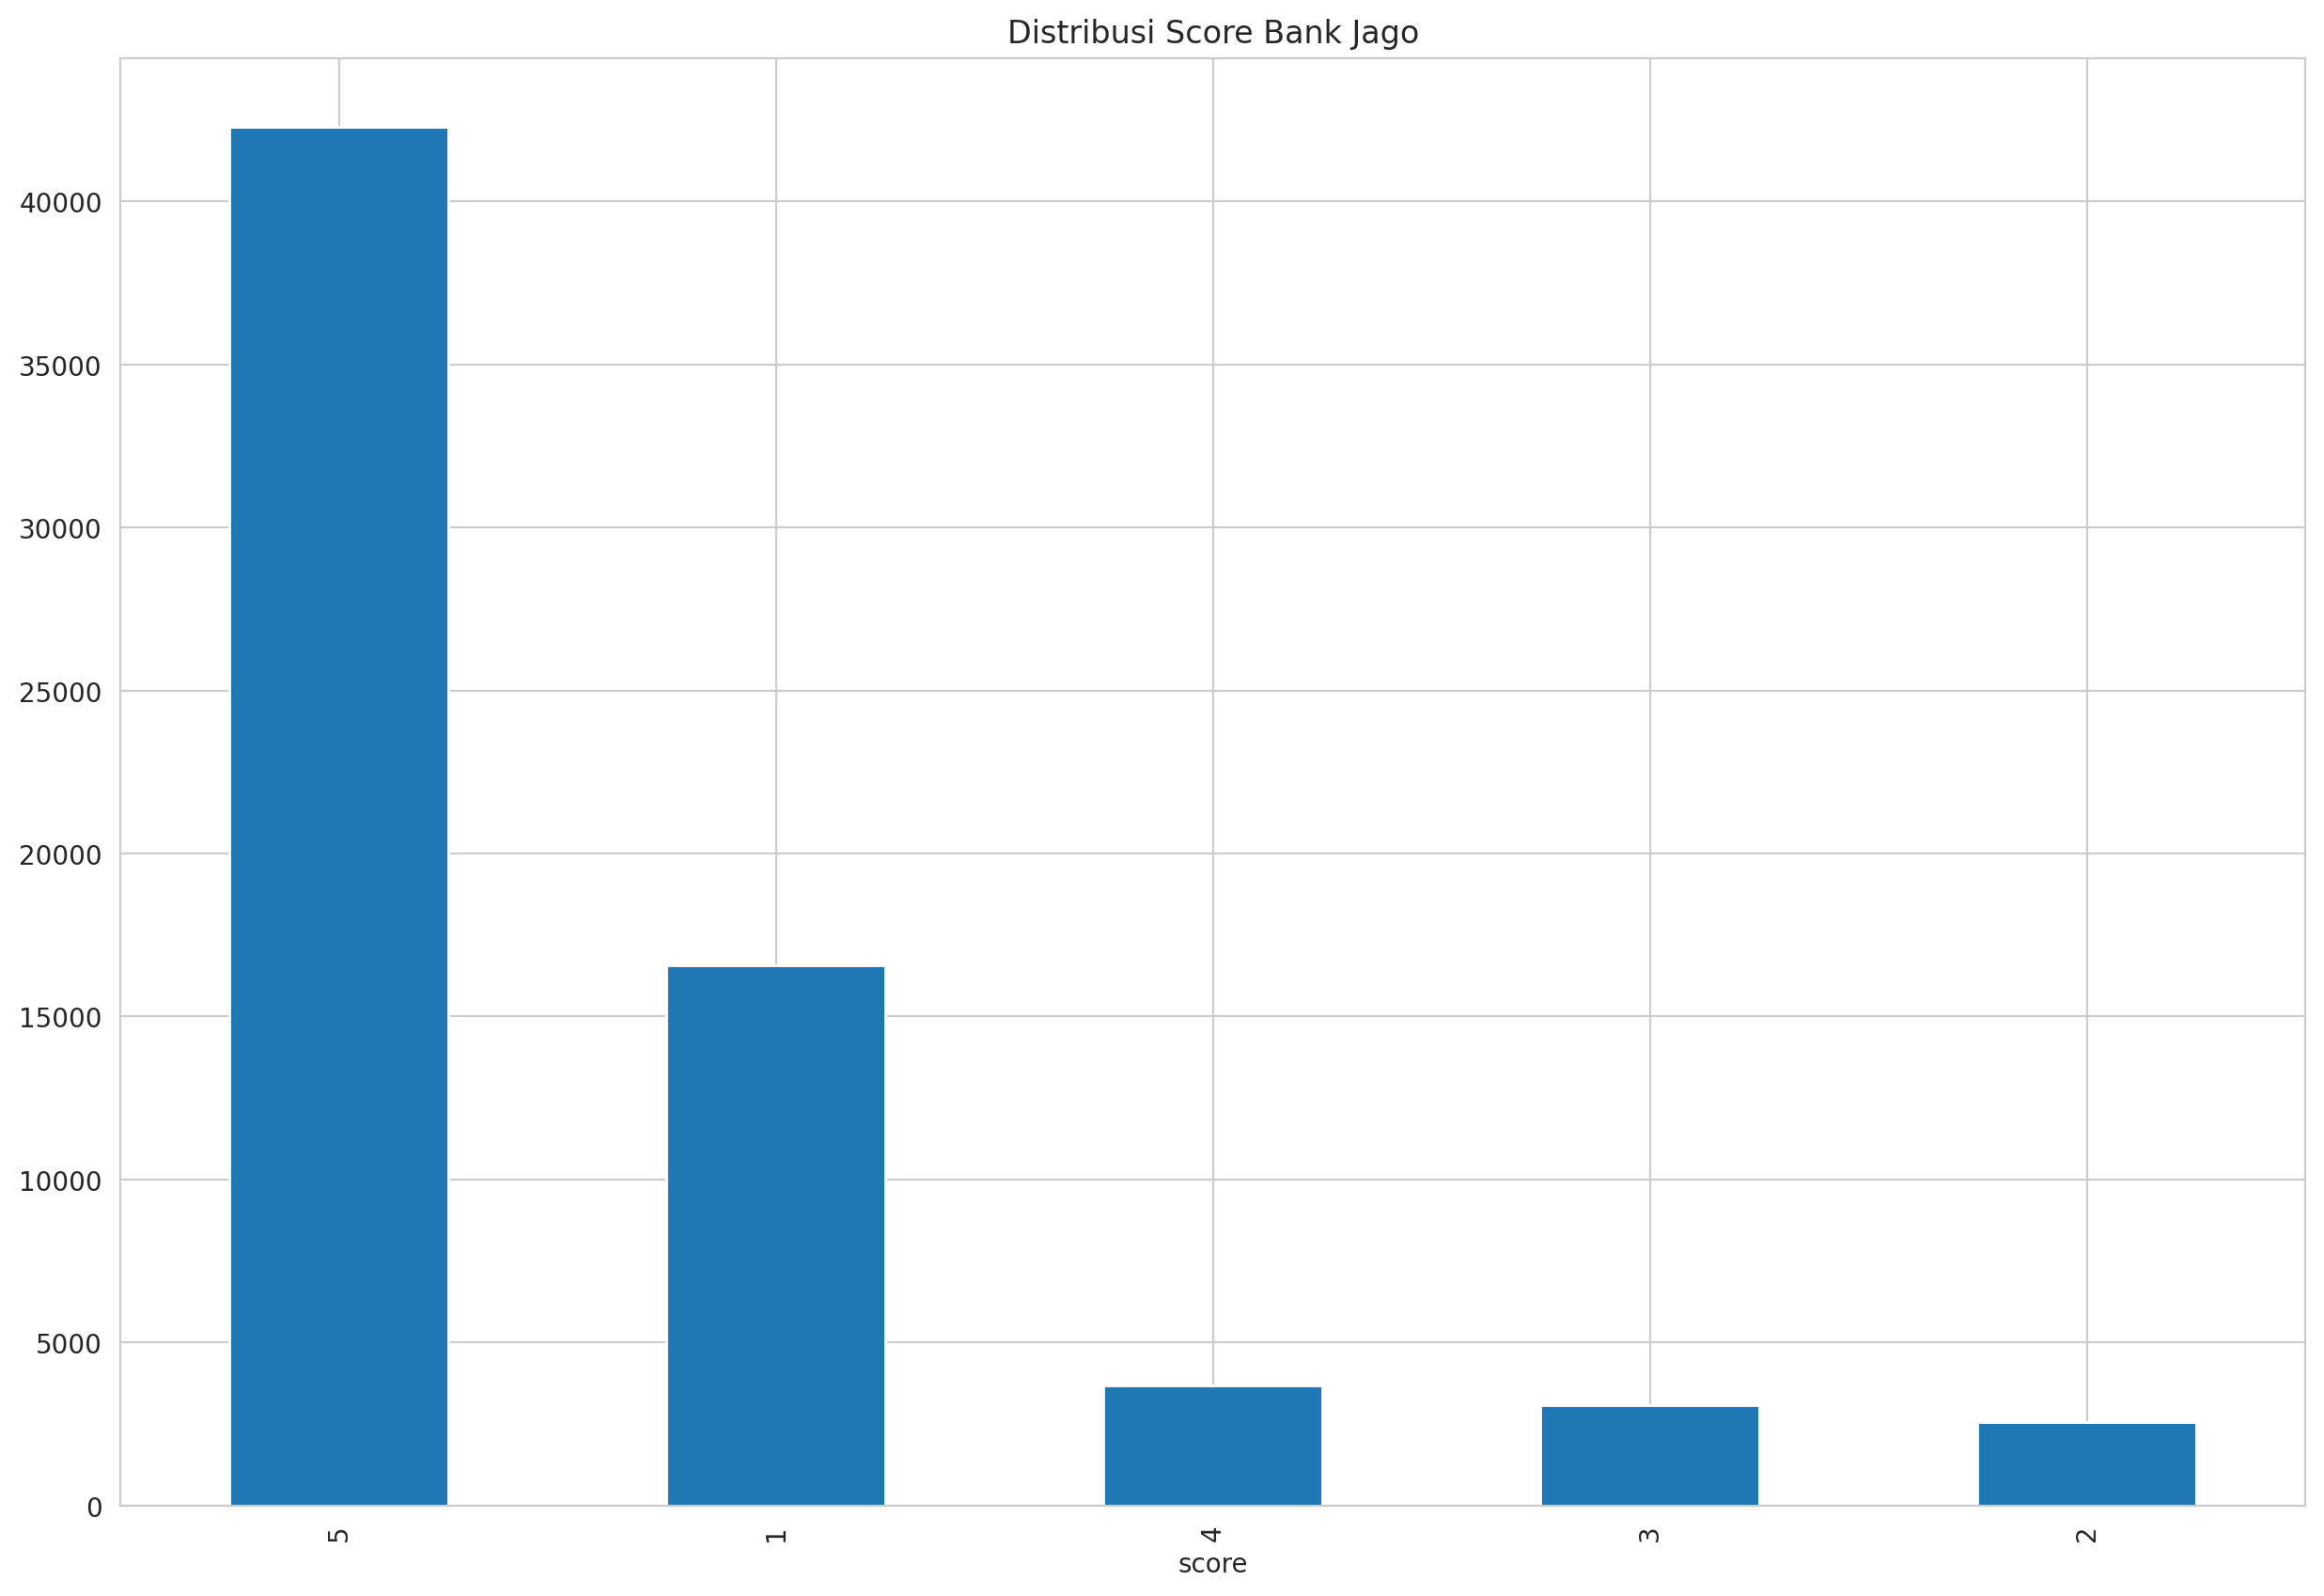

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,kata ny bisa meminjam kan uang .. ! sekali di ...,3,0.0,0.0,Neutral
1,ok amann,5,0.5,0.5,Positive
2,mengapa aplikasi bank jago menu saya tidak ada...,3,0.0,0.0,Neutral
3,the best,5,1.0,0.3,Positive
4,"kerenn, makasii bonusnya minn",5,0.0,0.0,Positive


In [9]:
# Distribusi score
print(df_jagorev['score'].value_counts())
df_jagorev['score'].value_counts().plot(kind='bar', title='Distribusi Score Bank Jago')
plt.show()

# TextBlob sentiment
df_jagorev['sentiment_polarity'] = df_jagorev['content'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)
df_jagorev['sentiment_subjective'] = df_jagorev['content'].apply(
    lambda x: TextBlob(str(x)).sentiment.subjectivity
)

# Sentiment rating berdasarkan score
df_jagorev['sentiment_rating'] = df_jagorev['score'].apply(
    lambda x: 'Positive' if x > 3 else ('Negative' if x < 3 else 'Neutral')
)

df_jagorev[['content','score','sentiment_polarity','sentiment_subjective','sentiment_rating']].head()


In [10]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()
stop_words = set(stopwords.words('indonesian'))

df_clean = df_jagorev[['content', 'score', 'sentiment_polarity', 'sentiment_subjective', 'sentiment_rating']].copy()
df_clean = df_clean.dropna(subset=['content']).reset_index(drop=True)

# 1. Lowering
df_clean['content'] = df_clean['content'].str.lower()

# 2. Punctuation Removal
df_clean['content'] = df_clean['content'].apply(
    lambda x: re.sub(r'[^a-zA-Z0-9\s]', ' ', str(x))
)

# 3. Tokenization
df_clean['content'] = df_clean['content'].apply(
    lambda x: word_tokenize(x)
)

# 4. Stopword Removal (NLTK Indonesian)
df_clean['content'] = df_clean['content'].apply(
    lambda tokens: [w for w in tokens if w not in stop_words and w.strip() != '']
)

# 5. Stemming (Sastrawi)
df_clean['content'] = df_clean['content'].apply(
    lambda tokens: [stemmer.stem(w) for w in tokens]
)

print("Pipeline selesai, sample:")
print(df_clean['content'].head(3))


Pipeline selesai, sample:
0    [ny, pinjam, uang, aju, blg, ny, blom, sedia, ...
1                                          [ok, amann]
2    [aplikasi, bank, jago, menu, dana, instan, pin...
Name: content, dtype: object


In [11]:
# Hitung frekuensi semua kata
all_words = [w for tokens in df_clean['content'] for w in tokens]
word_freq = Counter(all_words)

print("=== Top 50 ===")
print(word_freq.most_common(50))


=== Top 50 ===
[('jago', 17897), ('bank', 12870), ('aplikasi', 10172), ('nya', 8711), ('bagus', 7206), ('mantap', 6253), ('mudah', 4999), ('gak', 4992), ('akun', 4638), ('masuk', 4576), ('yg', 4509), ('ga', 4335), ('bantu', 4182), ('login', 4141), ('transaksi', 4012), ('uang', 3911), ('udah', 3726), ('aja', 3540), ('banget', 3502), ('saldo', 3311), ('daftar', 3100), ('tolong', 3028), ('apk', 2852), ('ya', 2640), ('transfer', 2462), ('kasih', 2462), ('hp', 2400), ('moga', 2391), ('ok', 2351), ('ribet', 2296), ('pakai', 2282), ('salah', 2263), ('pake', 2246), ('buka', 2182), ('data', 2161), ('email', 2124), ('baik', 2076), ('cepat', 1990), ('good', 1976), ('fitur', 1933), ('gk', 1895), ('susah', 1893), ('verifikasi', 1822), ('coba', 1811), ('keren', 1788), ('bintang', 1749), ('gratis', 1748), ('aman', 1650), ('kartu', 1536), ('layan', 1515)]


In [12]:

# Contoh kata yang kemungkinan muncul dan perlu dihapus:
custom_stopwords = {
    'jago', 'bank', 'aplikasi', 'app', 'yg', 'ga', 'gak',
    'nya', 'bs', 'aja', 'udah', 'udh', 'bgt', 'emg', 'blm'
}
stop_words.update(custom_stopwords)

# Re-apply stopword removal setelah update
df_clean['content'] = df_clean['content'].apply(
    lambda tokens: [w for w in tokens if w not in stop_words]
)


In [13]:
# Hitung ulang frekuensi setelah custom stopwords
all_words2 = [w for tokens in df_clean['content'] for w in tokens]
word_freq2 = Counter(all_words2)

# Rare words: muncul kurang dari 3 kali
rare_words = {w for w, c in word_freq2.items() if c < 3}
df_clean['content'] = df_clean['content'].apply(
    lambda tokens: [w for w in tokens if w not in rare_words]
)

# Common words: muncul lebih dari threshold (opsional, sesuaikan)
total_docs = len(df_clean)
common_words = {w for w, c in word_freq2.items() if c > total_docs * 0.8}
df_clean['content'] = df_clean['content'].apply(
    lambda tokens: [w for w in tokens if w not in common_words]
)

print(f"Rare words removed: {len(rare_words)}")
print(f"Common words removed: {len(common_words)}")


Rare words removed: 15142
Common words removed: 0


In [14]:
# Gabung token kembali ke string
df_clean['content'] = df_clean['content'].apply(lambda tokens: ' '.join(tokens))

# Hapus baris kosong hasil cleaning
df_clean = df_clean[df_clean['content'].str.strip() != ''].reset_index(drop=True)

df_clean.to_csv('cleandata.csv', index=False)
print(f"Clean data saved: {df_clean.shape}")
df_clean.head()


Clean data saved: (65082, 5)


,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,ny pinjam uang aju blg ny blom sedia aneh jga,3,0.0,0.0,Neutral
1,ok amann,5,0.5,0.5,Positive
2,menu dana instan pinjam dll,3,0.0,0.0,Neutral
3,the best,5,1.0,0.3,Positive
4,kerenn makasii bonus minn,5,0.0,0.0,Positive
